<a href="https://colab.research.google.com/github/rudrasharma-git/Mathematics-for-ML/blob/main/LDA_Wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_wine

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [8]:
wine = load_wine()

In [9]:
X = np.array(wine.data)

In [11]:
Y = np.array(wine.target)

In [12]:
Y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [13]:
wine

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [14]:
#PCA

In [15]:
from sklearn.decomposition import PCA

In [16]:
pca = PCA(n_components=2)

In [20]:
X_fit = pca.fit(X)

In [22]:
X_pca = X_fit.transform(X)

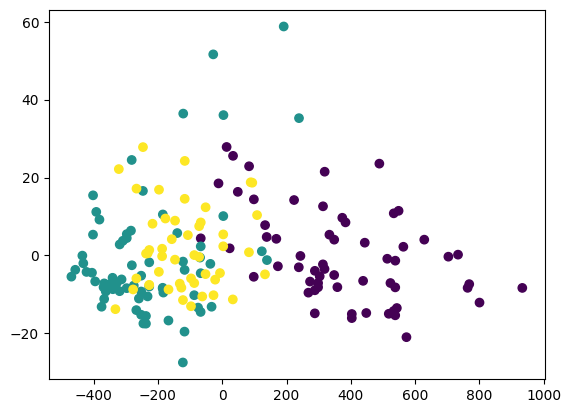

In [24]:
plt.scatter(X_pca[:,0],X_pca[:,1], c = Y)

In [25]:
#LDA

In [26]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X,Y)

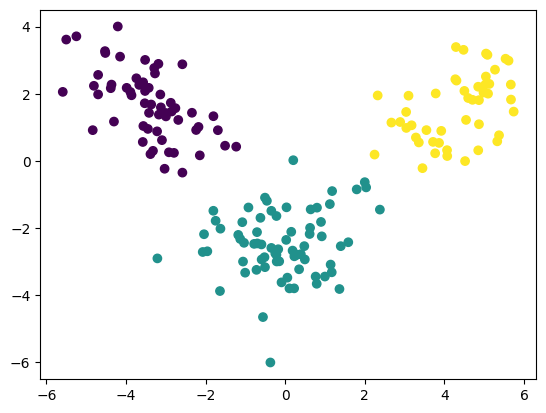

In [27]:
plt.scatter(X_lda[:,0],X_lda[:,1], c = Y)

In [28]:
#CLASSIFIER using LDA

In [29]:
from sklearn.model_selection import train_test_split
xtrain, xtest,ytrain, ytest = train_test_split(X_lda,Y,test_size=0.3)

In [30]:
lda.fit(xtrain,ytrain)

LinearDiscriminantAnalysis(n_components=2)

In [33]:
Yres = lda.predict(xtest)


In [34]:
print(ytest)
print(Yres)
print(ytest-Yres)

[1 1 0 1 2 1 1 1 1 0 0 2 2 1 0 0 1 1 1 2 0 2 2 0 0 0 2 0 1 2 2 2 1 2 0 1 2
 1 2 2 1 2 0 0 1 2 1 0 1 1 2 0 1 0]
[1 1 0 1 2 1 1 1 1 0 0 2 2 1 0 0 1 1 1 2 0 2 2 0 0 0 2 0 1 2 2 2 1 2 0 1 2
 1 2 2 1 2 0 0 1 2 1 0 1 1 2 0 1 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
